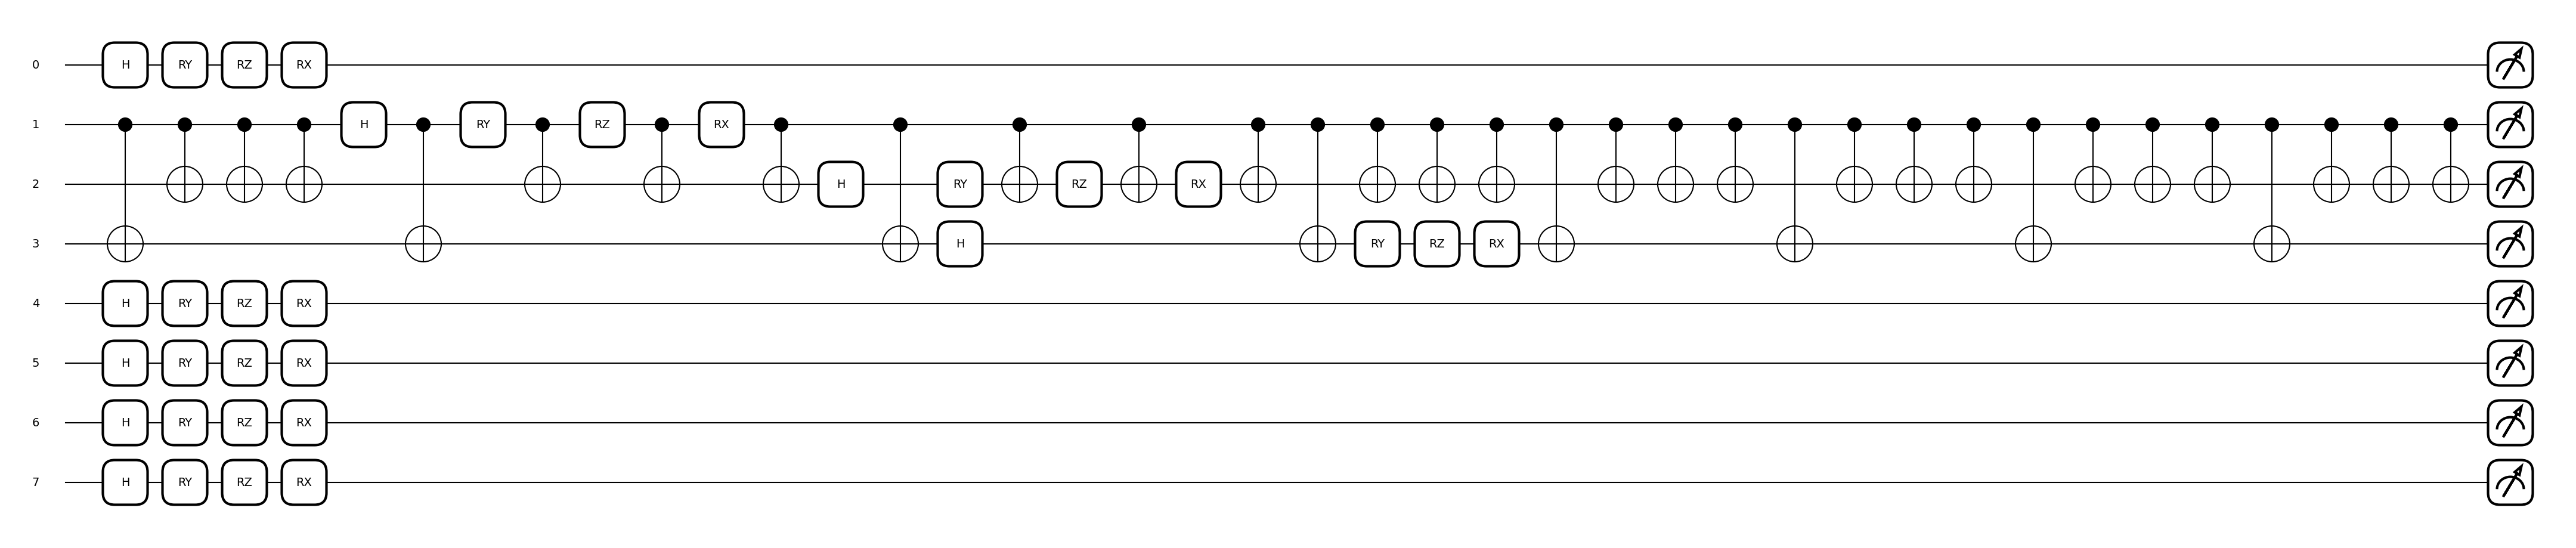

In [1]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Sample training data
import lightgbm as lgb
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from sklearn.svm import SVR


df=pd.read_csv(r'C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\DATASET\2D electronic properties2.csv',encoding='ISO-8859–1')        
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y = df['Band gap ']

# defining target
x=df[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]

# Splitting the dataset into training and test set.  
from sklearn.model_selection import train_test_split  
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.07, random_state=2)  

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)

# Quantum setup
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

# Define quantum feature map
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.CNOT(wires=[1, 3])
        qml.RY(np.pi,wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RZ(x[i % len(x)], wires=i)
        qml.CNOT(wires=[1, 2])
        qml.RX(np.pi*1.5, wires=i)
        qml.CNOT(wires=[1, 2])

# Define a quantum node
@qml.qnode(dev)
def circuit(x):
    quantum_feature_map(x)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

# Visualize the quantum circuit for a sample
sample_x = X_train_scaled[0][:n_qubits]  # Take the first training sample, limit to `n_qubits`

# Draw the circuit using matplotlib
fig, ax = qml.draw_mpl(circuit)(sample_x)
plt.show()


Generating quantum states...
Number of states: 2000
Number of fidelity samples: 1000
Minimum fidelity: 3.987810596825816e-14
Maximum fidelity: 0.4274161626921967
Mean fidelity: 0.007868321323520807

QUANTUM FEATURE MAP EXPRESSIBILITY
Number of qubits       : 8
Number of samples      : 2000
Number of fidelity pairs: 1000
KL divergence          : 0.69484353


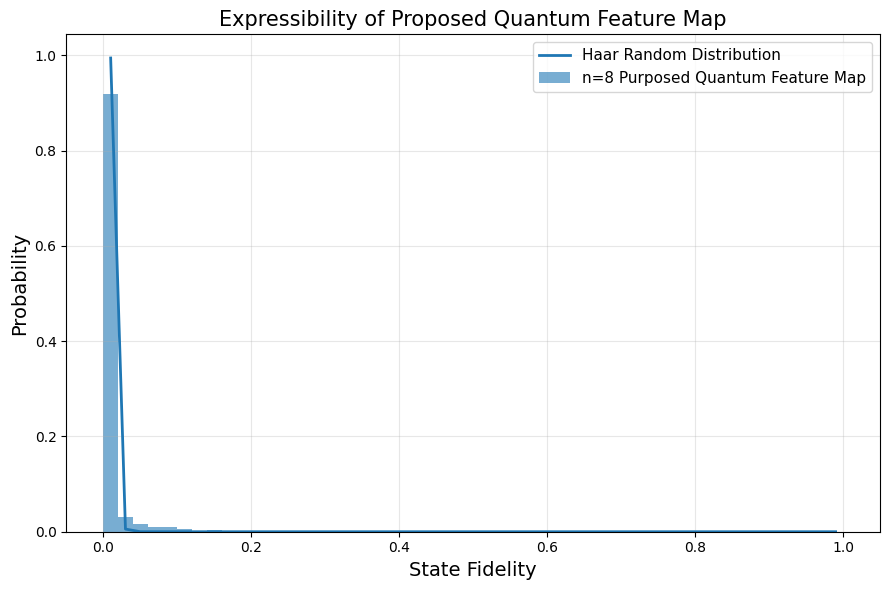

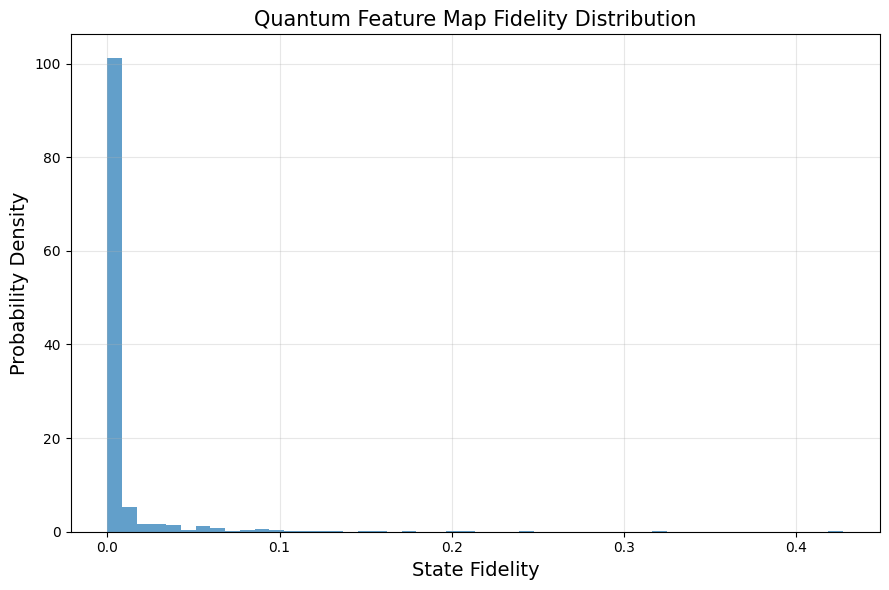

In [4]:
# ============================================================
# EXPRESSIBILITY OF YOUR PENNYLANE QUANTUM FEATURE MAP
# Compatible with your existing circuit
# ============================================================

import pennylane as qml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import entropy




# ============================================================
# STATEVECTOR CIRCUIT
# ============================================================

@qml.qnode(dev)
def state_circuit(x):

    quantum_feature_map(x)

    return qml.state()


# ============================================================
# GENERATE RANDOM INPUTS
# ============================================================

n_samples = 2000

np.random.seed(42)

X_random = np.random.uniform(
    low=-np.pi,
    high=np.pi,
    size=(n_samples, n_qubits)
)


# ============================================================
# CALCULATE QUANTUM STATES
# ============================================================

print("Generating quantum states...")

states = []

for x in X_random:

    state = state_circuit(x)

    states.append(
        np.asarray(state)
    )

states = np.asarray(states)

print(
    "Number of states:",
    len(states)
)


# ============================================================
# CALCULATE PAIRWISE FIDELITIES
# ============================================================

# ============================================================
# PAIRWISE FIDELITY
# ============================================================

fidelities = []

n_pairs = n_samples // 2

for i in range(n_pairs):

    # Select two independent quantum states
    psi = states[2 * i]
    phi = states[2 * i + 1]

    # Inner product <psi|phi>
    overlap = np.vdot(psi, phi)

    # Fidelity |<psi|phi>|^2
    F = np.abs(overlap) ** 2

    fidelities.append(F)

fidelities = np.asarray(fidelities)

print(
    "Number of fidelity samples:",
    len(fidelities)
)

print(
    "Minimum fidelity:",
    np.min(fidelities)
)

print(
    "Maximum fidelity:",
    np.max(fidelities)
)

print(
    "Mean fidelity:",
    np.mean(fidelities)
)


# ============================================================
# HAAR RANDOM FIDELITY DISTRIBUTION
# ============================================================

dimension = 2 ** n_qubits

n_bins = 50

bins = np.linspace(
    0,
    1,
    n_bins + 1
)

bin_centers = (
    bins[:-1] +
    bins[1:]
) / 2


# Haar probability density:
#
# P(F) = (d - 1)(1-F)^(d-2)
#
# where d = 2^n

haar_pdf = (
    (dimension - 1)
    *
    (1 - bin_centers)
    ** (dimension - 2)
)


# Convert PDF into discrete probabilities

haar_prob = (
    haar_pdf /
    np.sum(haar_pdf)
)


# ============================================================
# QUANTUM FEATURE MAP FIDELITY DISTRIBUTION
# ============================================================

qfm_hist, _ = np.histogram(
    fidelities,
    bins=bins
)

qfm_prob = (
    qfm_hist /
    np.sum(qfm_hist)
)


# ============================================================
# AVOID ZERO PROBABILITIES
# ============================================================

epsilon = 1e-12

qfm_prob = qfm_prob + epsilon

haar_prob = haar_prob + epsilon


qfm_prob = (
    qfm_prob /
    np.sum(qfm_prob)
)

haar_prob = (
    haar_prob /
    np.sum(haar_prob)
)


# ============================================================
# EXPRESSIBILITY
# ============================================================

KL_divergence = entropy(
    qfm_prob,
    haar_prob
)


print("\n============================================")
print("QUANTUM FEATURE MAP EXPRESSIBILITY")
print("============================================")

print(
    f"Number of qubits       : {n_qubits}"
)

print(
    f"Number of samples      : {n_samples}"
)

print(
    f"Number of fidelity pairs: {n_pairs}"
)

print(
    f"KL divergence          : {KL_divergence:.8f}"
)

print("============================================")


# ============================================================
# PLOT 1:
# FIDELITY DISTRIBUTION VS HAAR DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.bar(
    bin_centers,
    qfm_prob,
    width=1 / n_bins,
    alpha=0.6,
    label="n=8 Purposed Quantum Feature Map"
)

plt.plot(
    bin_centers,
    haar_prob,
    linewidth=2,
    label="Haar Random Distribution"
)

plt.xlabel(
    "State Fidelity",
    fontsize=14
)

plt.ylabel(
    "Probability",
    fontsize=14
)

plt.title(
    "Expressibility of Proposed Quantum Feature Map",
    fontsize=15
)

plt.legend(
    fontsize=11
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# PLOT 2:
# FIDELITY HISTOGRAM
# ============================================================

plt.figure(
    figsize=(9, 6)
)

plt.hist(
    fidelities,
    bins=n_bins,
    density=True,
    alpha=0.7
)

plt.xlabel(
    "State Fidelity",
    fontsize=14
)

plt.ylabel(
    "Probability Density",
    fontsize=14
)

plt.title(
    "Quantum Feature Map Fidelity Distribution",
    fontsize=15
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()